## Importação das bibliotecas e dataset


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns

In [2]:
sns.set_theme(style="white", context="notebook")

path = Path() / "data" / "credit_card_fraud_2026.csv"

data = pd.read_csv(path)

## Análise Exploratória de Dados(EDA)

In [3]:
data.head(5)

,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  str    
 3   card_type                     20000 non-null  str    
 4   auth_method                   20000 non-null  str    
 5   channel                       20000 non-null  str    
 6   device_type                   20000 non-null  str    
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  customer_age                  20000 non-null  int64  
 13  account_bala

In [5]:
data.describe()

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,132.424597,8.950827,3.191650,22.139525,46.937550,49.669400,3316.662598,0.181300,19.807735,11.533650,2.998750,37.400390,0.281250,0.016950
std,5773.647028,256.963666,8.838745,1.779544,22.120960,6.768577,18.494032,4350.720948,0.422302,12.366301,6.925335,2.004956,17.061415,0.529209,0.129087
min,1.000000,1.000000,0.010000,0.000000,0.000000,22.000000,18.000000,52.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5000.750000,26.235000,2.590000,2.000000,6.337500,42.000000,34.000000,1019.140000,0.000000,10.700000,6.000000,1.000000,25.600000,0.000000,0.000000
50%,10000.500000,57.510000,6.210000,3.000000,15.505000,47.000000,50.000000,2007.685000,0.000000,18.800000,12.000000,3.000000,35.700000,0.000000,0.000000
75%,15000.250000,131.752500,12.432500,4.000000,30.820000,51.000000,66.000000,3944.120000,0.000000,27.600000,18.000000,5.000000,47.300000,0.000000,0.000000
max,20000.000000,6872.690000,87.050000,12.000000,216.190000,74.000000,81.000000,127125.860000,3.000000,74.400000,23.000000,6.000000,100.000000,4.000000,1.000000


In [6]:
data.select_dtypes(include="str").nunique()

merchant_category    12
card_type             5
auth_method           5
channel               5
device_type           8
dtype: int64

In [7]:
for col in data.select_dtypes(include=["object", "string"]):
    print(f"Coluna: {col}: \n{data[col].value_counts()}\n")

Coluna: merchant_category: 
merchant_category
Online Retail      3416
Groceries          3242
Restaurants        2534
Electronics        2032
Fuel               1565
Travel             1420
Utilities          1330
Healthcare         1237
Gaming             1036
Streaming          1010
Gift Cards          617
Crypto Exchange     561
Name: count, dtype: int64

Coluna: card_type: 
card_type
Visa          8417
Mastercard    6629
Amex          2135
RuPay         1796
Discover      1023
Name: count, dtype: int64

Coluna: auth_method: 
auth_method
3D Secure            5554
OTP                  4792
PIN                  4173
Biometric            3093
No Authentication    2388
Name: count, dtype: int64

Coluna: channel: 
channel
Online         6810
POS            5191
Contactless    3400
In-App         3225
ATM            1374
Name: count, dtype: int64

Coluna: device_type: 
device_type
Android Phone    5503
iPhone           4179
POS Terminal     3162
Windows PC       2623
Mac              1359

### Divisão Treino e Teste


In [8]:
from sklearn.model_selection import train_test_split

X = data.drop(columns=["transaction_id", "is_fraud"])
y = data["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Análise Gráfica dos Dados


### Variáveis Númericas


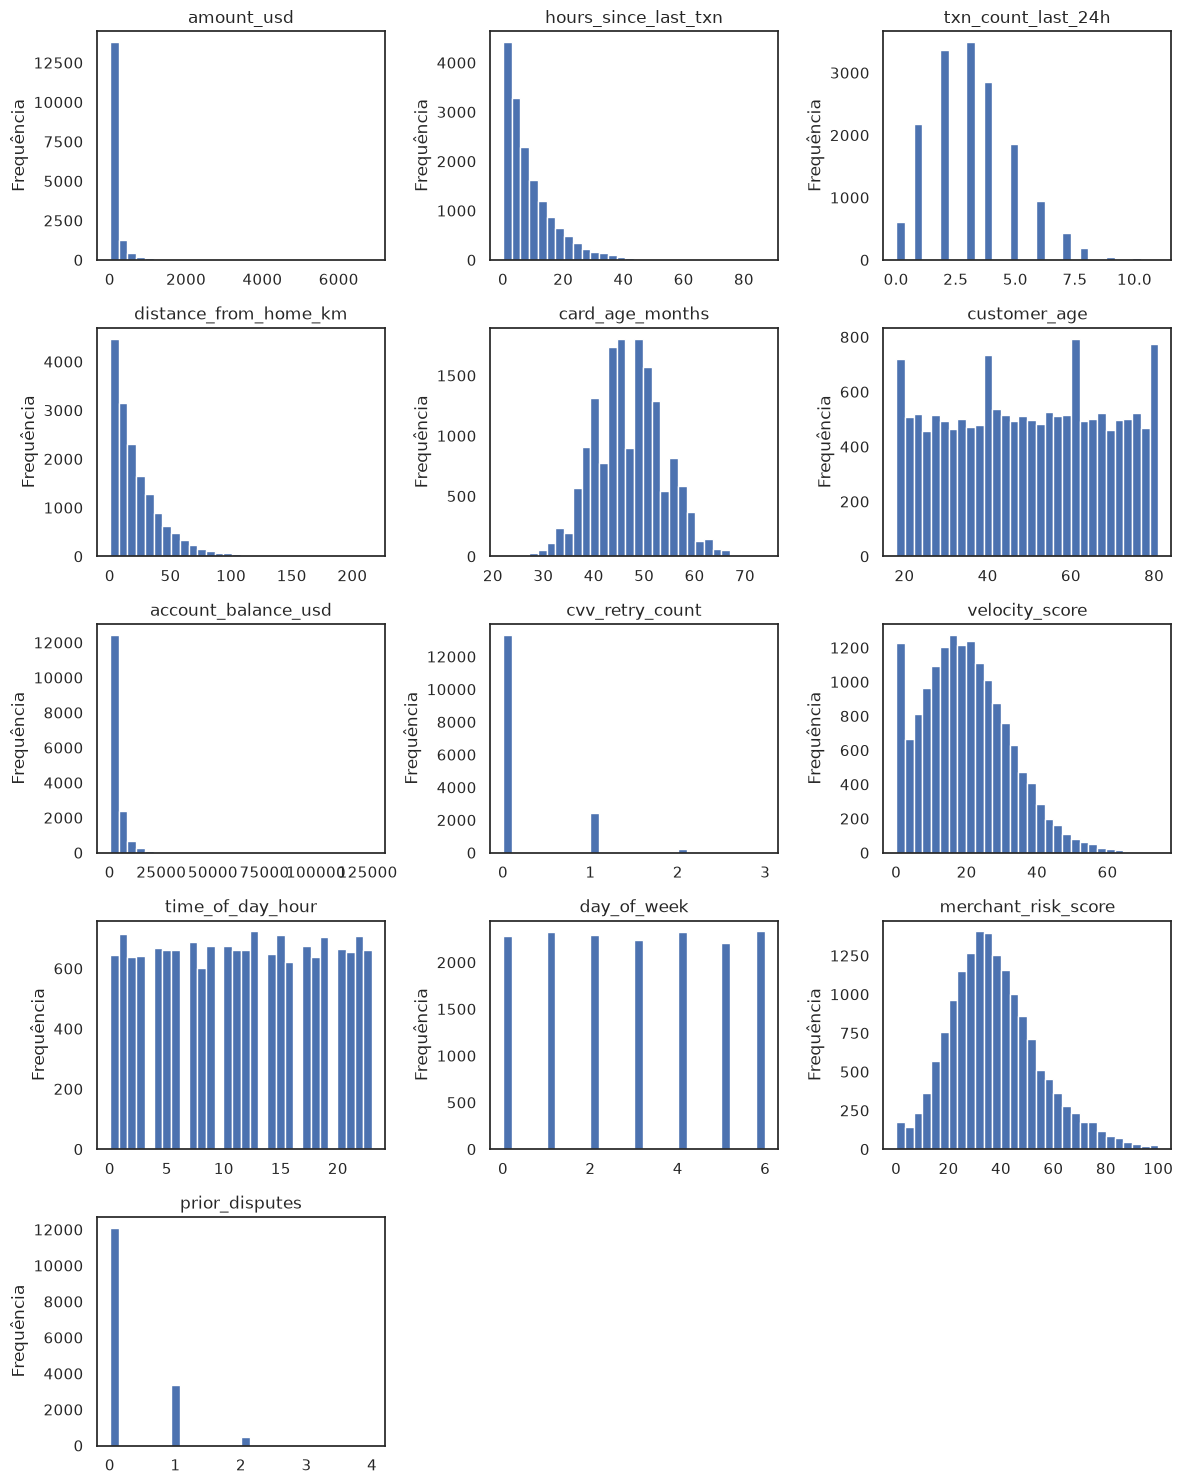

In [9]:
import matplotlib.pyplot as plt

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3 * n_rows))

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.hist(X_train[col], bins=30, edgecolor="white")

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequência")

# Remove gráficos vazios
for ax in axes[len(numeric_cols) :]:
    ax.remove()

plt.tight_layout()
plt.show()

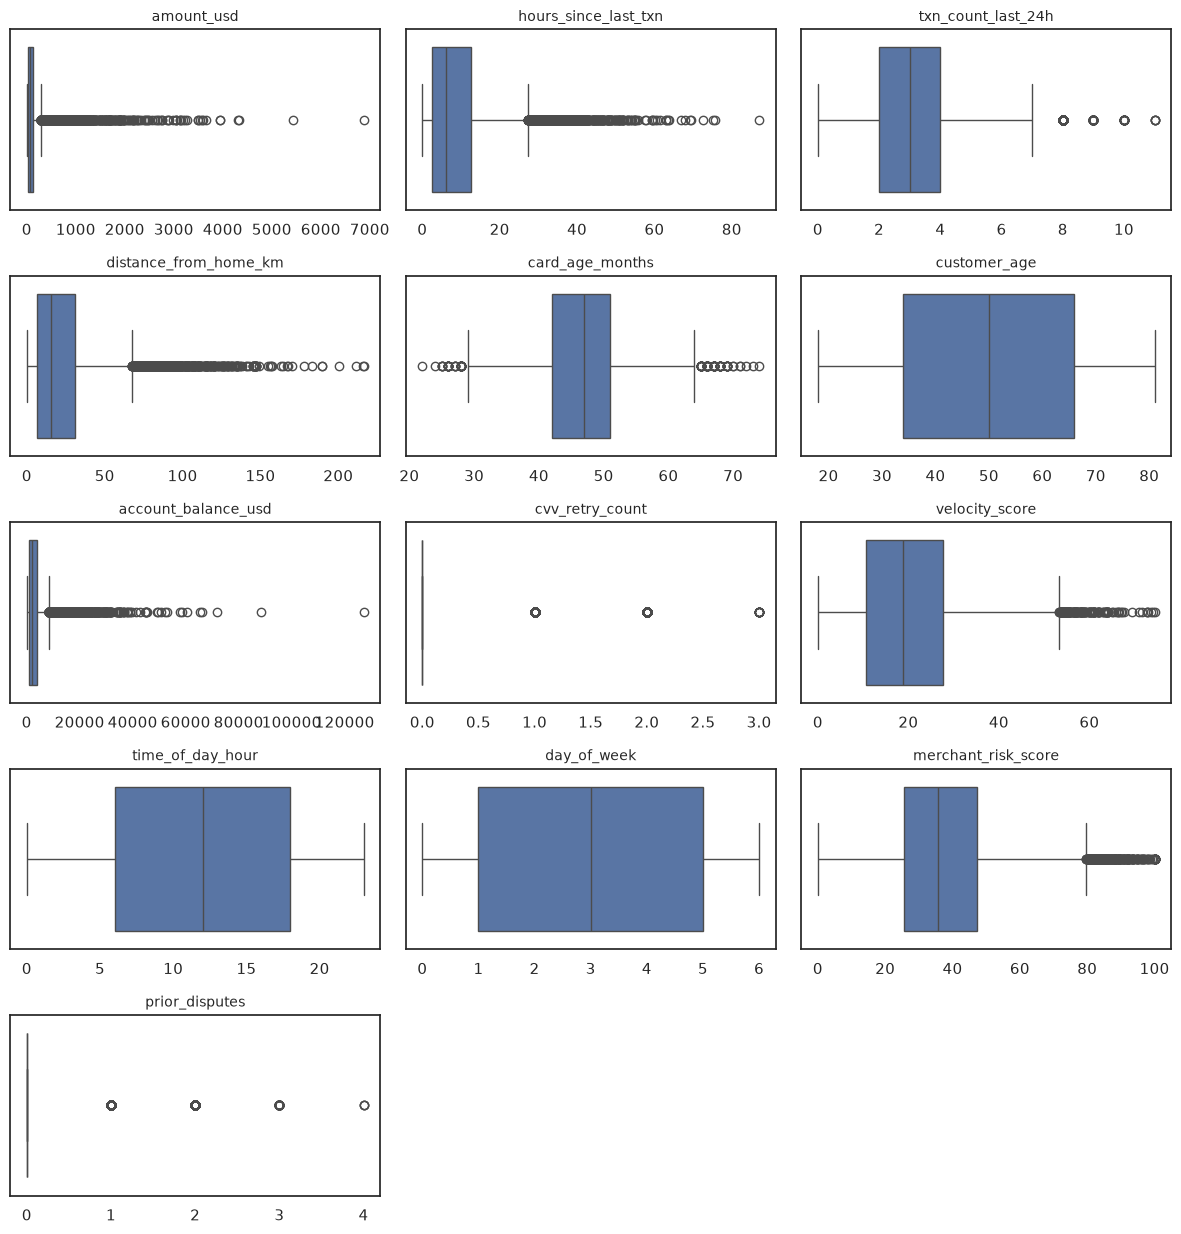

In [10]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2.5 * n_rows))

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(
        x=X_train[col],
        ax=ax,
    )

    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[len(numeric_cols) :]:
    ax.remove()

plt.tight_layout()
plt.show()

In [11]:
counts = y_train.value_counts()
percentages = y_train.value_counts(normalize=True) * 100

print(f"Não fraude: {counts.get(0, 0)} ({percentages.get(0, 0):.2f}%)")
print(f"Fraude:     {counts.get(1, 0)} ({percentages.get(1, 0):.2f}%)")

Não fraude: 15729 (98.31%)
Fraude:     271 (1.69%)


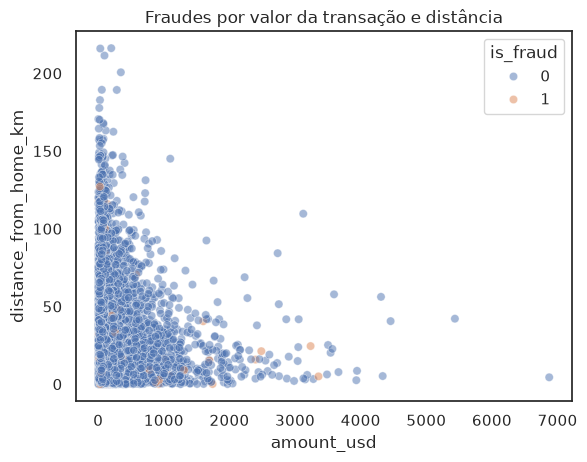

In [12]:
sns.scatterplot(
    data=data,
    x="amount_usd",
    y="distance_from_home_km",
    hue="is_fraud",
    alpha=0.5
)

plt.title("Fraudes por valor da transação e distância")
plt.show()

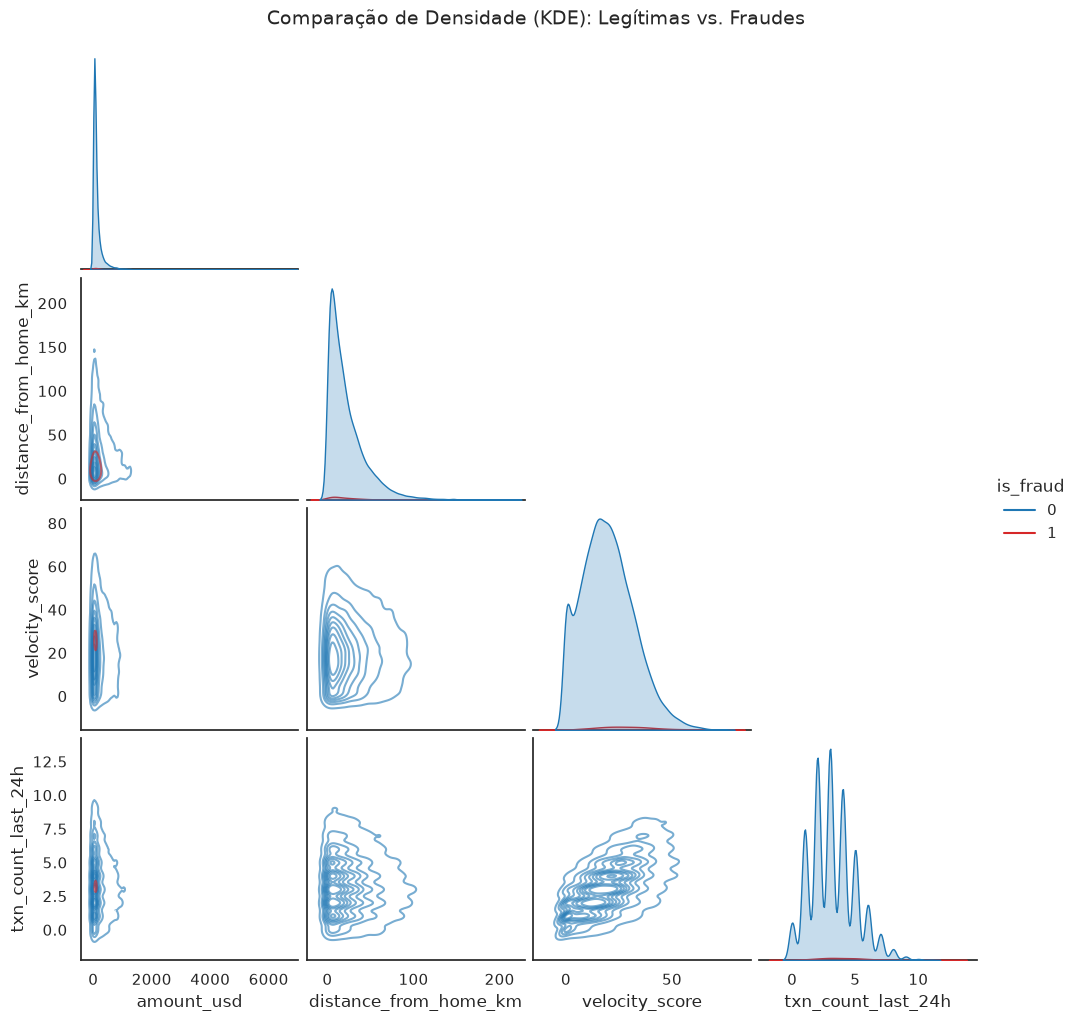

In [13]:
# Configuração visual do pairplot comparativo
sns.pairplot(
    data=data[
        [
            "amount_usd",
            "distance_from_home_km",
            "velocity_score",
            "txn_count_last_24h",
            "is_fraud",
        ]
    ],
    hue="is_fraud",
    kind="kde",
    corner=True,  # Opcional: remove a metade superior duplicada para limpar o visual
    palette={0: "tab:blue", 1: "tab:red"},  # Vermelho para destaque nas fraudes
    plot_kws={"alpha": 0.6},  # Transparência para ver a intersecção das curvas
)

plt.suptitle(
    "Comparação de Densidade (KDE): Legítimas vs. Fraudes", y=1.02, fontsize=14
)
plt.show()

### Variáveis categoricas


/tmp/ipykernel_10868/3052653247.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include="object").columns


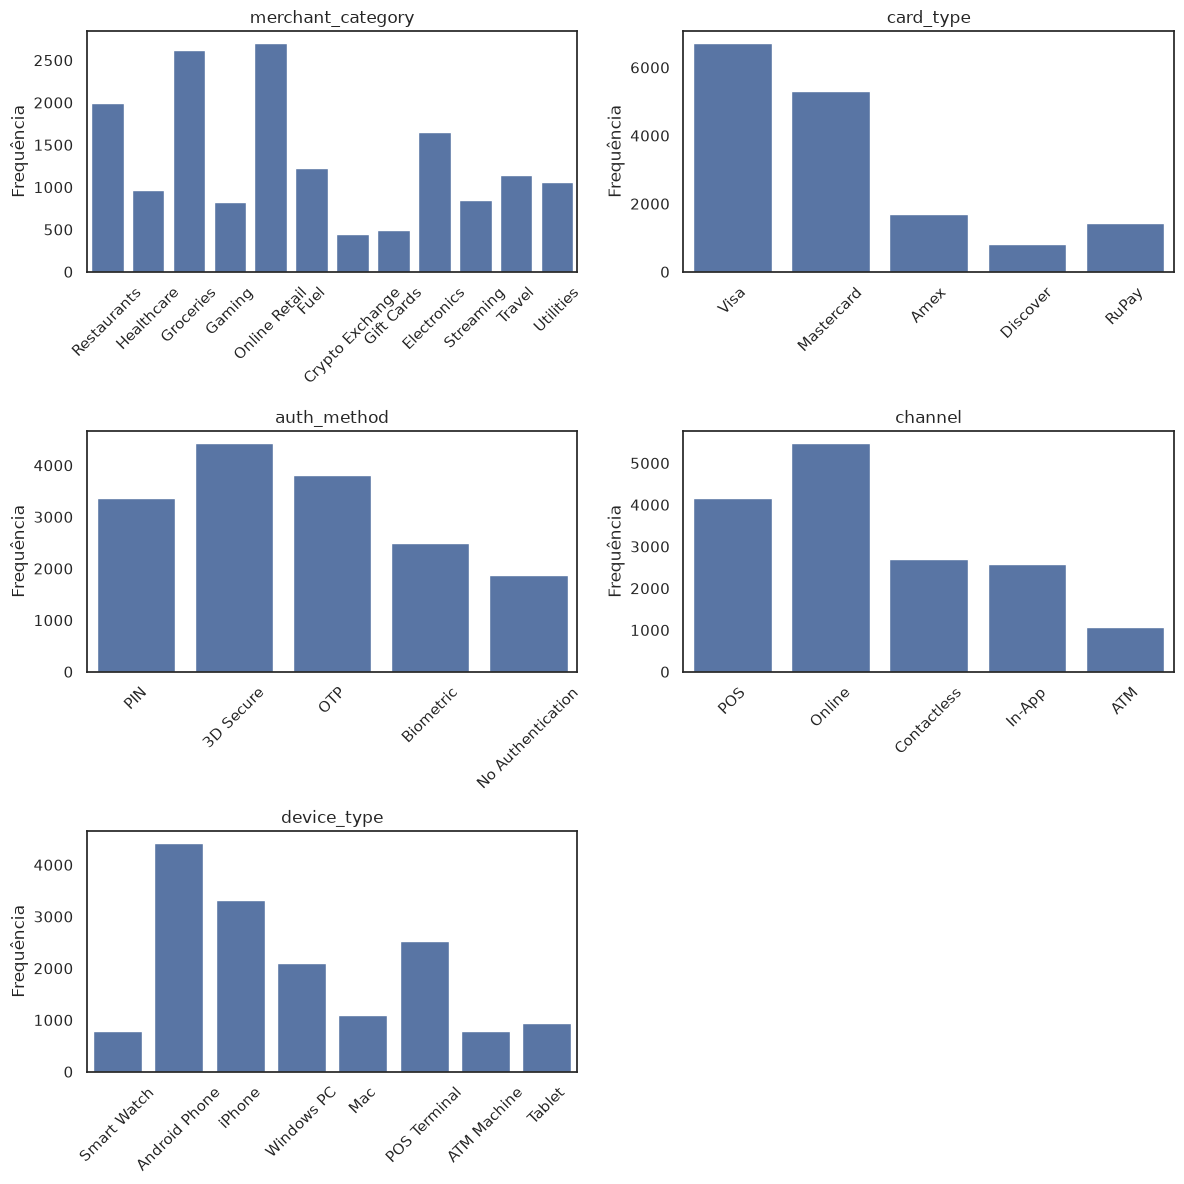

In [14]:
categorical_cols = X_train.select_dtypes(include="object").columns

n_cols = 2
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))

axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=X_train, x=col, ax=ax)

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequência")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(categorical_cols) :]:
    ax.remove()

plt.tight_layout()
plt.show()

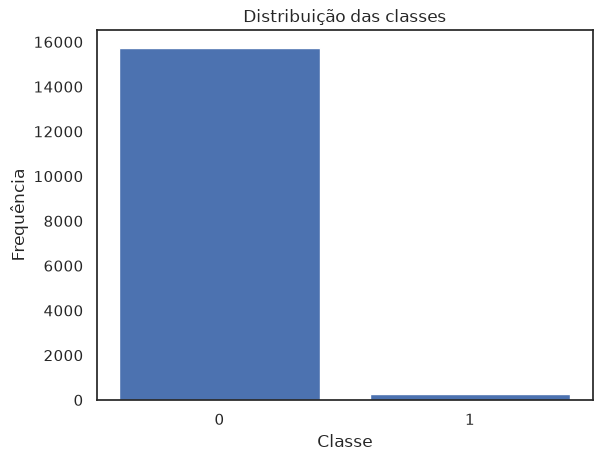

In [15]:
counts = y_train.value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)

plt.xlabel("Classe")
plt.ylabel("Frequência")
plt.title("Distribuição das classes")

plt.show()

## Classificador Burro(Dummy Classifier)


In [16]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")

dummy_clf.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.98,0.02]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](24,)","['amount_usd','merchant_category','card_type',..., 'is_ai_generated_scam_attempt','merchant_risk_score','prior_disputes']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,24
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [17]:
print(
    f"Predição do Dummy Classifier para X_train[0]: {dummy_clf.predict(X_train.iloc[[0]])}"
)
print(f"Predição probalidade: {dummy_clf.predict_proba(X_train.iloc[[0]])}")
print(f"Valor real: {y_train.iloc[0]}")

Predição do Dummy Classifier para X_train[0]: [0]
Predição probalidade: [[1. 0.]]
Valor real: 0


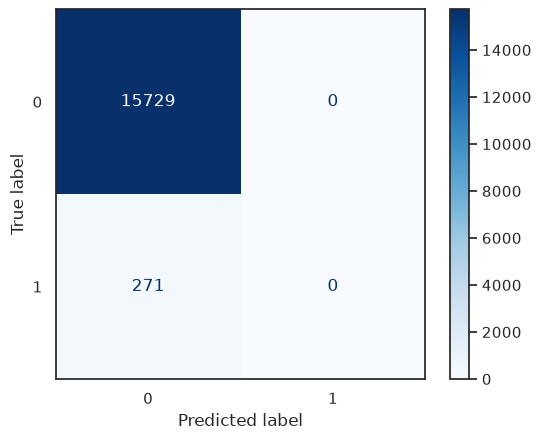

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

dummy_y_train_pred = dummy_clf.predict(y_train)

dummy_clf_cm = confusion_matrix(y_train, dummy_y_train_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=dummy_clf_cm,
    display_labels=dummy_clf.classes_,
    
)

disp.plot(cmap="Blues")
plt.show()

In [19]:
from sklearn.metrics import recall_score, f1_score, accuracy_score, precision_score

print(f"Recall: {recall_score(y_train, dummy_y_train_pred)}")
print(f"F1 Score: {f1_score(y_train, dummy_y_train_pred)}")
print(f"Accuracy: {accuracy_score(y_train, dummy_y_train_pred)}")
print(f"Precision: {precision_score(y_train, dummy_y_train_pred)}")

Recall: 0.0
F1 Score: 0.0
Accuracy: 0.9830625
Precision: 0.0


/mnt/shared/dev/IA/machine_learning/classification/credit_card_fraud/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Resultados do Dummy Classifier

Apesar de o Dummy Classifier apresentar uma **taxa de acerto de aproximadamente 98%**, isso não significa que ele seja um bom modelo. Na verdade, seu desempenho demonstra justamente um dos principais problemas da **acurácia em datasets(conjuntos de dados) desbalanceados**.

O Dummy Classifier é um classificador que utiliza estratégias extremamente simples para realizar suas previsões. Neste caso, o modelo prevê praticamente todos os exemplos como pertencentes à **classe majoritária**, classe 0, sem levar em consideração as características (_features_) dos dados.

A métrica acurácia teve um valor alto porque existe um **grande desbalanceamento entre as classes**. Se aproximadamente 98% dos exemplos pertencem à classe 0, um modelo que simplesmente classifica todos os exemplos como classe 0 acertará aproximadamente 98% das vezes, ou seja, o modelo sempre "puxará" para a classe majoritária.

Isso pode nos levar a uma conclusão enganosa:

> "Se o modelo acerta 98% das previsões, então ele é um modelo muito bom."

**Não necessariamente.**

Nesse cenário, a acurácia está escondendo o fato de que o modelo praticamente **não consegue identificar a classe minoritária**, classe 1.

Por isso, quando há classes desbalanceadas, é importante analisar outras métricas além da acurácia.

#### Precisão (_Precision_)

A precisão responde à seguinte pergunta:

> **Entre todas as observações que o modelo classificou como positivas, quantas realmente eram positivas?**

Ela está relacionada à **confiabilidade das previsões positivas**.

Uma precisão alta significa que, quando o modelo prevê a classe positiva, há uma grande probabilidade de essa previsão estar correta.

#### Recall

O recall responde à pergunta:

> **Entre todas as observações que realmente pertencem à classe positiva, quantas o modelo conseguiu identificar?**

Também podemos interpretá-lo como a **capacidade do modelo de encontrar os casos positivos**.

Um recall baixo significa que muitos exemplos que realmente pertencem à classe positiva estão sendo classificados incorretamente como negativos.

#### F1-Score

O F1-Score combina **precisão e recall** em uma única métrica. Ele é especialmente útil quando queremos considerar simultaneamente a capacidade do modelo de identificar corretamente os positivos e a confiabilidade dessas previsões.

### Conclusão

O Dummy Classifier serve como um base para comparação. Seu resultado de aproximadamente 98% de acurácia mostra que essa métrica, isoladamente, pode ser bastante enganosa em um conjunto de dados desbalanceado.

Portanto, para avaliar modelos nesse problema, não devemos observar apenas a acurácia. É necessário analisar métricas como **Precision, Recall e F1-Score**, especialmente em relação à classe minoritária.


## SVM


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(), categorical_cols),
])


svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(
        kernel='rbf',
        class_weight='balanced',
        random_state=42
    ))
])

svm_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['amount_usd','merchant_category','card_type',..., 'is_ai_generated_scam_attempt','merchant_risk_score','prior_disputes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`


--- Desempenho nos Dados de Treino ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     15729
           1       0.48      1.00      0.65       271

    accuracy                           0.98     16000
   macro avg       0.74      0.99      0.82     16000
weighted avg       0.99      0.98      0.98     16000



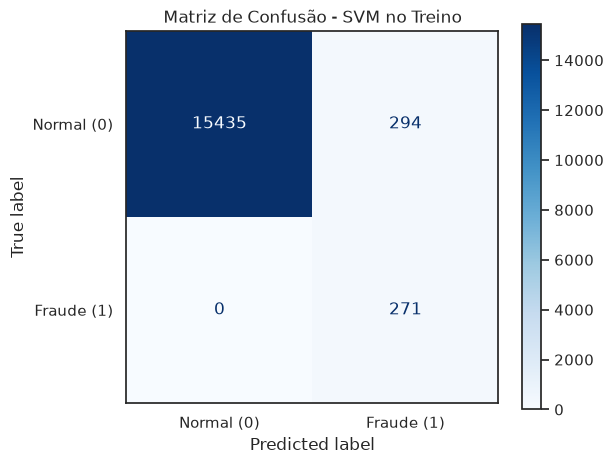

In [21]:
# Fazer a previsão sobre os PRÓPRIOS dados de treino
from sklearn.metrics import classification_report

y_pred_train = svm_pipeline.predict(X_train)

print("\n--- Desempenho nos Dados de Treino ---")
print(classification_report(y_train, y_pred_train))

# Visualizar a Matriz de Confusão do Treino
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_train, y_pred_train)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Fraude (1)'])
disp.plot(cmap='Blues', ax=ax)

plt.title('Matriz de Confusão - SVM no Treino')
plt.show()

Temos um modelo melhor que o Dummy Classifier, pois este consegui identificar fraudes, mas este ainda não é um modelo bom. Afinal, ao analisar as métricas é possível que a precisão para classificar uma ocorrência como fraude está muito baixa. Isso significa que o modelo não é muito confiável quando prevê que uma determinada observação é fraude.

O Recall para ambas classes está muito bom. É preciso melhorar ainda a capacidade do modelo de separar fraudes e não fraudes.

Para isso, iremos alterar o threshold utilizado pelo modelo para definir o valor da função de decisão em uma classe.

O threshold é um valor de decisão, um valor de limiar. Se o valor retornado pela função de decisão for maior ou igual ao threshold, a observação será classificada como classe positiva, neste caso é fraude. Caso seja menor, será classificada como classe negativa, não fraude

```text
valor da função de decisão >= threshold → fraude
valor da função de decisão < threshold  → não fraude

In [22]:
# Testemos o limiar = 0.5, importante destacar que o valor padrão é 0
threshold = 0.5

y_scores_train = svm_pipeline.decision_function(X_train)


## Comparemos os valores da função de decisão usando o threshold para torna-los uma saída 0 ou 1.
y_pred_new_threshold = (y_scores_train > threshold).astype(int)

y_pred_new_threshold

array([0, 0, 0, ..., 0, 0, 0], shape=(16000,))


--- Desempenho nos Dados de Treino ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15729
           1       0.79      1.00      0.89       271

    accuracy                           1.00     16000
   macro avg       0.90      1.00      0.94     16000
weighted avg       1.00      1.00      1.00     16000



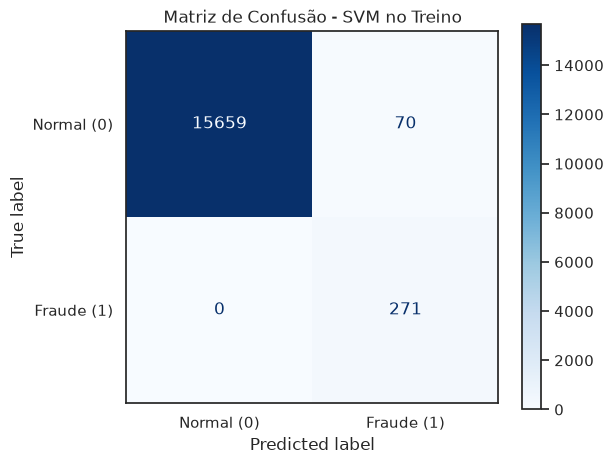

In [23]:
print("\n--- Desempenho nos Dados de Treino ---")
print(classification_report(y_train, y_pred_new_threshold))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_train, y_pred_new_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Fraude (1)'])
disp.plot(cmap='Blues', ax=ax)

plt.title('Matriz de Confusão - SVM no Treino')
plt.show()


Vimos que alterar o threshold de 0 para 0.5 melhorou nossas métricas.

Podemos testar diferentes valores de threshold e observar o comportamento de Precision, Recall e F1-Score para cada um deles. Porém, fazer essa busca manualmente é trabalhoso.

Para analisar diretamente o equilíbrio entre a capacidade do modelo de evitar falsos alarmes e a sua capacidade de encontrar os casos positivos em diferentes thresholds, utilizamos a **Curva Precision-Recall (PR Curve)**.


#### Curva Precision-Recall

A Curva Precision-Recall mostra o desempenho de um classificador binário para diferentes valores de threshold, sendo a curva ideal para datasets desbalanceados (onde a classe positiva é rara).

Ela relaciona:

* **Precision (Precisão)** → Proporção de acertos entre todas as previsões classificadas como positivas.
* **Recall (Sensibilidade / TPR)** → Proporção de casos positivos reais que o modelo conseguiu identificar.

Precision:

$$
Precision = \frac{TP}{TP + FP}
$$

Recall:

$$
Recall = \frac{TP}{TP + FN}
$$

Cada ponto da curva representa a combinação de Precision e Recall obtida pelo modelo para um determinado threshold.

Queremos tanto uma Precision alta quanto um Recall alto. Por isso, os **pontos mais próximos do canto superior direito são os mais interessantes**.

Average Precision (PR-AUC): 0.8514
Melhor Threshold: 0.9995 | F1: 0.9748


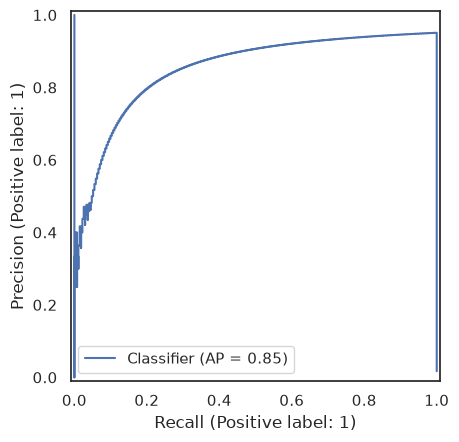

In [24]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
from sklearn.metrics import precision_recall_curve

PrecisionRecallDisplay.from_predictions(y_train, y_scores_train)
ap = average_precision_score(y_train, y_scores_train)
print(f"Average Precision (PR-AUC): {ap:.4f}")


precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores_train)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
print(
    f"Melhor Threshold: {best_thresh:.4f} | F1: {f1_scores[best_idx]:.4f}"
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15729
           1       0.95      1.00      0.97       271

    accuracy                           1.00     16000
   macro avg       0.98      1.00      0.99     16000
weighted avg       1.00      1.00      1.00     16000



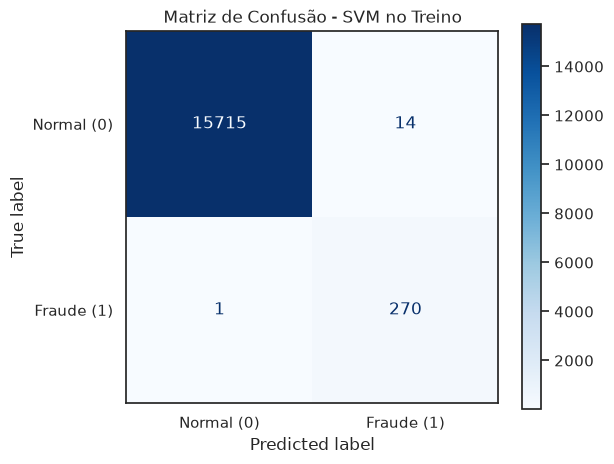

In [25]:
y_pred_best_threshold = (y_scores_train > best_thresh).astype(int)

print(classification_report(y_train, y_pred_best_threshold))

# 5. Visualizar a Matriz de Confusão do Treino
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_train, y_pred_best_threshold)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Fraude (1)'])
disp.plot(cmap='Blues', ax=ax)

plt.title('Matriz de Confusão - SVM no Treino')
plt.show()


> *"Agora temos um modelo perfeito, métricas muito altas para ambas as classes (Fraude e Não Fraude), certo ?"*

Ainda não. Pode ser ou não um bom modelo. 

Métricas altas indicam que o modelo teve um bom desempenho nos dados avaliados, mas isso não garante que ele terá o mesmo desempenho em dados novos.

#### Generalização
Generalização é a capacidade de um modelo produzir boas previsões para dados que não foram vistos durante o treinamento.

Responde à pergunta:
>  "Quando o modelo receber novos dados, ele conseguirá continuar fazendo boas previsões?"

O objetivo é que o modelo aprenda padrões que existem nos dados, e não apenas memorize os exemplos utilizados no treinamento.

Por isso, devemos comparar o desempenho do modelo em diferentes datasets:

- Treinamento: dados utilizados para aprender padrões

- Teste: **dados não utilizados durante o treinamento ou desenvolvimento**, usados para verificar generalização do modelo.

O ideal é que o modelo apresente desempenho semelhante nos dados de treinamento e teste. 

Quando o desempenho no treino é muito melhor ao teste, o modelo está com overfitting.

Quando o modelo apresenta desempenho ruim tanto no treino quanto no teste, podemos estar diante de underfitting.

Como ainda serão testados outros algoritmos de classificação, não podemos utilizar o conjunto de teste ainda.
Porque estaríamos reutilizando o conjunto de teste e, pior ainda, usar o conjunto de teste para tomada de decisões como: 
- qual algoritmo é melhor;
- quais hiperparâmetros utilizar;
- qual configuração apresenta o melhor desempenho;
 
estaremos adaptando nossas decisões ao conjunto de teste.

Isso compromete a capacidade do conjunto de teste de avaliar a generalização do modelo para dados realmente não utilizados durante o desenvolvimento.

Por isso, além do conjunto de treinamento e testes, precisamos de um conjunto para validação para usarmos para tomar decisões durante o desenvolvimento do nosso modelo.

Poderia dividir o conjunto de treinamento para criar um conjunto de validação, mas utilizaremos validação cruzada para avaliar o desempenho do modelo.


O conjunto de teste será reservado para a avaliação final do modelo escolhido.

#### Validação cruzada(Cross-Validation)
É uma técnica utilizada para avaliar o desempenho de um modelo em diferentes subconjuntos dos dados.

Como funciona? 
- Divisão dos dados: O dataset é dividido igualmente em k-folds(partes);
- Treinamento: O modelo é treinamento utilizando k - 1 folds
- Avaliação: avalia usando a fold restante;
- Repete o processo até que todas as k folds sejam utilizados como teste;
- Calcula a média das métricas obtidas.


Tipos de divisões dos dados: 
- K-Fold: divide k partes iguais;
- Divisão Estratificada K-Fold: divide considerando a proporção das classes dos dados em cada fold;
- Temporal: preserva ordem cronologica sem embaralhamento randômico.

In [26]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
        n_splits=5,
        shuffle=True, # Mantém proporção dos dados. Se no dataset original, para cada 1 fraude, há 10 transações normais, ele irá manter essa proporção de 1/10
        random_state=42
)

results_best_threshold = []

for i, (train_index, test_index) in enumerate(cv.split(X_train, y_train)):
    cv_X_train = X_train.iloc[train_index]  
    cv_y_train = y_train.iloc[train_index]
    
    cv_X_test = X_train.iloc[test_index]
    cv_y_test = y_train.iloc[test_index]
    
    model = svm_pipeline.fit(cv_X_train, cv_y_train)
    
    cv_scores = model.decision_function(cv_X_test)
    
    cv_predict = (cv_scores > best_thresh).astype(int)
    
    results_best_threshold.append({
        "fold": i,
        "f1": f1_score(cv_y_test, cv_predict),
        "precision": precision_score(cv_y_test, cv_predict),
        "recall": recall_score(cv_y_test, cv_predict),
        "roc_auc": roc_auc_score(cv_y_test, cv_scores),
        "accuracy": accuracy_score(cv_y_test, cv_predict),
    })


In [27]:
results_df = pd.DataFrame(results_best_threshold)

results_df = results_df.round({
    "f1": 4,
    "precision": 4,
    "recall": 4,
    "roc_auc": 4,
    "accuracy": 4
})

summary = results_df.drop(columns="fold").agg(["mean", "std"]).round(4)

print("\nResultados por fold:")
print(results_df.to_string(index=False))

print("\nMédia e desvio-padrão:")
print(summary)



Resultados por fold:
 fold     f1  precision  recall  roc_auc  accuracy
    0 0.0345     0.2500  0.0185   0.7802    0.9825
    1 0.0328     0.1429  0.0185   0.7329    0.9816
    2 0.0364     1.0000  0.0185   0.8326    0.9834
    3 0.0000     0.0000  0.0000   0.7867    0.9819
    4 0.1017     0.7500  0.0545   0.7766    0.9834

Média e desvio-padrão:
          f1  precision  recall  roc_auc  accuracy
mean  0.0411     0.4286  0.0220   0.7818    0.9826
std   0.0371     0.4263  0.0199   0.0354    0.0008


> "*Por que essas métricas estão tão baixas para esse threshold ? As métricas antes, no treinamento, estavam altas..*"

Isso é um cenário de overfitting no qual o modelo se ajusta excessivamente aos dados de treinamento, memorizando detalhes e ruídos em vez de aprender padrões reais. O modelo apresenta bom desempenho no treinamento, porém falha ao fazer previsão para novos dados.

A capacidade de generalização desse modelo para esse threshold (~0.998) é baixa e modelo sofre de overfitting.

Analisemos se o modelo padrão, sem alterar o threshold irá sofrer de overfitting.

Quando otimizamos um threshold de decisão utilizando todo o conjunto de treino, estamos sujeitos ao overfitting de limiar. O valor extremo obtido na curva curva de precisão do treino decorou os ruídos do treino. Na Validação Cruzada, o limiar ideal varia a cada fold. Portanto, a busca pelo threshold ótimo deve ser feita dentro de cada fold da validação cruzada ou em um conjunto de validação separado, e nunca memorizada diretamente do treino inteiro.

In [28]:
results_default_threshold = []

for i, (train_index, test_index) in enumerate(cv.split(X_train, y_train)):
    cv_X_train = X_train.iloc[train_index]  
    cv_y_train = y_train.iloc[train_index]
    
    cv_X_test = X_train.iloc[test_index]
    cv_y_test = y_train.iloc[test_index]
    
    model = svm_pipeline.fit(cv_X_train, cv_y_train)
        
    cv_predict = model.predict(cv_X_test)
    
    results_default_threshold.append({
        "fold": i,
        "f1": f1_score(cv_y_test, cv_predict),
        "precision": precision_score(cv_y_test, cv_predict),
        "recall": recall_score(cv_y_test, cv_predict),
        "roc_auc": roc_auc_score(cv_y_test, cv_predict),
        "accuracy": accuracy_score(cv_y_test, cv_predict),
    })


In [29]:
results_default_df = pd.DataFrame(results_default_threshold)

results_default_df = results_default_df.round({
    "f1": 4,
    "precision": 4,
    "recall": 4,
    "roc_auc": 4,
    "accuracy": 4
})

summary = results_default_df.drop(columns="fold").agg(["mean", "std"]).round(4)

print("\nResultados por fold:")
print(results_default_df.to_string(index=False))

print("\nMédia e desvio-padrão:")
print(summary)



Resultados por fold:
 fold     f1  precision  recall  roc_auc  accuracy
    0 0.1846     0.1579  0.2222   0.6009    0.9669
    1 0.1290     0.0990  0.1852   0.5781    0.9578
    2 0.2482     0.2048  0.3148   0.6469    0.9678
    3 0.2174     0.1786  0.2778   0.6279    0.9662
    4 0.1739     0.1446  0.2182   0.5978    0.9644

Média e desvio-padrão:
          f1  precision  recall  roc_auc  accuracy
mean  0.1906     0.1570  0.2436   0.6103    0.9646
std   0.0451     0.0396  0.0518   0.0271    0.0040


### Conclusão e Análise do Desempenho do SVM

#### 1. Comparação de Thresholds e Generalização

 Ao avaliar o modelo usando a **Validação Cruzada (5-Fold Stratified)**, observamos que:
* **Threshold Padrão ($0.0$):** Apresentou uma capacidade de generalização ligeiramente superior ao "melhor threshold" ajustado manualmente no treino.
* **Overfitting por Otimização no Treino:** A busca por um *threshold* ideal diretamente na curva de precisão/recall do conjunto de treinamento fez o modelo memorizar ruídos específicos daqueles dados. Quando avaliado em dados não vistos (folds de validação), o desempenho desabou.
* **Resultado Geral:** Mesmo com o *threshold* padrão, a capacidade de generalização continuou **muito ruim** (Recall e F1-Score ruins para a detecção de fraude).

---

#### 2. Por que o SVM com Kernel RBF falhou?

O SVM com kernel RBF tenta mapear os dados para um espaço de maior dimensão com o objetivo de encontrar um **hiperplano geométrico que separe as classes**.

No nosso caso, o algoritmo **não conseguiu captar a relação entre os dados** pelos seguintes motivos:
* **Falta de Separabilidade Geométrica:** As variáveis não seguem um padrão espacial linearmente ou radialmente divisível.
* **Sobreposição Extrema (Overlap):** Como vimos previamente na *Análise Exploratória (KDE)*, a classe minoritária (Fraude) está concentrada exatamente nas mesmas regiões de maior volume da classe majoritária (Legítima).
* **Esmagamento da Margem:** Diante dessa sobreposição em um dataset altamente desbalanceado, a margem de decisão do SVM acaba sendo empurrada para esmagar a classe de fraude como se fosse ruído.

---

Isso mostra a importância de escolher o algoritmo correto para a estrutura dos dados:
> Ao escolher um algoritmo, é preciso levar em consideração se ele é adequado para a natureza dos dados. Não existe um modelo melhor ou que sirva para todos os problemas.

**Próximo Passo:**
Como o SVM (separação geométrica) não funcionou bem para esses dados, iremos testar **algoritmos baseados em Árvores de Decisão (como XGBoost)**.

## Random Forest

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [31]:
results_rf = []

for i, (train_index, test_index) in enumerate(cv.split(X_train, y_train)):
    cv_X_train, cv_y_train = X_train.iloc[train_index], y_train.iloc[train_index]
    cv_X_test, cv_y_test = X_train.iloc[test_index], y_train.iloc[test_index]
    
    rf_pipeline.fit(cv_X_train, cv_y_train)
    
    cv_predict = rf_pipeline.predict(cv_X_test)
    cv_scores = rf_pipeline.predict_proba(cv_X_test)[:, 1]
    
    results_rf.append({
        "fold": i,
        "f1": f1_score(cv_y_test, cv_predict),
        "precision": precision_score(cv_y_test, cv_predict),
        "recall": recall_score(cv_y_test, cv_predict),
        "roc_auc": roc_auc_score(cv_y_test, cv_scores),
        "accuracy": accuracy_score(cv_y_test, cv_predict),
        
    })

/mnt/shared/dev/IA/machine_learning/classification/credit_card_fraud/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/shared/dev/IA/machine_learning/classification/credit_card_fraud/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/mnt/shared/dev/IA/machine_learning/classification/credit_card_fraud/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted sampl

In [32]:
rf_df = pd.DataFrame(results_rf).round(4)
summary_rf = rf_df.drop(columns="fold").agg(["mean", "std"]).round(4)

print("\nResultados Random Forest (Validação Cruzada):")
print(summary_rf)


Resultados Random Forest (Validação Cruzada):
          f1  precision  recall  roc_auc  accuracy
mean  0.0073     0.2000  0.0037   0.8209    0.9830
std   0.0163     0.4472  0.0083   0.0321    0.0003


O Random Forest constrói um conjunto de árvores de decisão e combina suas previsões por votação. No entanto, em conjuntos de dados altamente desbalanceados, a probabilidade média calculada pelas árvores raramente ultrapassa o limite padrão de 50% exigido para classificar a classe minoritária.

Isso nos leva a um comportamento em que o modelo atinge uma **acurácia alta de aproximadamente 98,3%**, mas falha quase que totalmente em identificar as fraudes.

### Conclusão e Próximos Passos

O Random Forest não deve ser descartado apenas por esse resultado inicial. É possível alterar a regra de decisão do método `.predict()`, que exige uma probabilidade maior que 50% para classificar uma transação como fraude, um patamar raramente atingido em eventos tão raros, classes desbalanceadas.

Para tornar modelos baseados em árvores viáveis nesse contexto, precisamos lidar diretamente com o desbalanceamento na tomada de decisão. Utilizando a `.predict_proba()` para alterar a regra de decisão do modelo, podendo reduzi-la a fim de identificar mais fraudes.

**Próximo Passo:**
Em vez de testar limiares manuais no Random Forest, vamos passar para o **XGBoost (Extreme Gradient Boosting)**. Além de ser otimizado para dados tabulares, o XGBoost possui um hiperparâmetro nativo (`scale_pos_weight`) feito exatamente para lidar com distribuições severamente desbalanceadas, penalizando de forma mais inteligente os erros cometidos na classe minoritária.

## XGBoost

In [33]:
from xgboost import XGBClassifier

# Calculando a proporção exata entre transações normais (0) e fraudes (1)
class_counts = y_train.value_counts()
spw = class_counts[0] / class_counts[1]

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        scale_pos_weight=spw,
        random_state=42,
        eval_metric='logloss', # Evita avisos de métricas descontinuadas
        n_jobs=-1
    ))
])

In [34]:
results_xgb = []

for i, (train_index, test_index) in enumerate(cv.split(X_train, y_train)):
    cv_X_train, cv_y_train = X_train.iloc[train_index], y_train.iloc[train_index]
    cv_X_test, cv_y_test = X_train.iloc[test_index], y_train.iloc[test_index]
    
    # Treina o modelo
    xgb_pipeline.fit(cv_X_train, cv_y_train)
    
    # Faz as previsões (com o threshold padrão nativo, já ajustado pelo scale_pos_weight)
    cv_predict = xgb_pipeline.predict(cv_X_test)
    cv_scores = xgb_pipeline.predict_proba(cv_X_test)[:, 1]
    
    results_xgb.append({
        "fold": i,
        "f1": f1_score(cv_y_test, cv_predict),
        "precision": precision_score(cv_y_test, cv_predict),
        "recall": recall_score(cv_y_test, cv_predict),
        "roc_auc": roc_auc_score(cv_y_test, cv_scores),
        "accuracy": accuracy_score(cv_y_test, cv_predict),
    })

In [35]:
xgb_df = pd.DataFrame(results_xgb).round(4)
summary_xgb = xgb_df.drop(columns="fold").agg(["mean", "std"]).round(4)

print("\nResultados por fold (XGBoost):")
print(xgb_df.to_string(index=False))

print("\nMédia e desvio-padrão:")
print(summary_xgb)


Resultados por fold (XGBoost):
 fold     f1  precision  recall  roc_auc  accuracy
    0 0.0811     0.1500  0.0556   0.7731    0.9788
    1 0.0930     0.1250  0.0741   0.7380    0.9756
    2 0.1370     0.2632  0.0926   0.8015    0.9803
    3 0.1515     0.4167  0.0926   0.8087    0.9825
    4 0.1194     0.3333  0.0727   0.7912    0.9816

Média e desvio-padrão:
          f1  precision  recall  roc_auc  accuracy
mean  0.1164     0.2576  0.0775   0.7825    0.9798
std   0.0294     0.1227  0.0156   0.0282    0.0027


O melhor Threshold encontrado foi: 0.1901
F1-Score máximo projetado: 0.1697


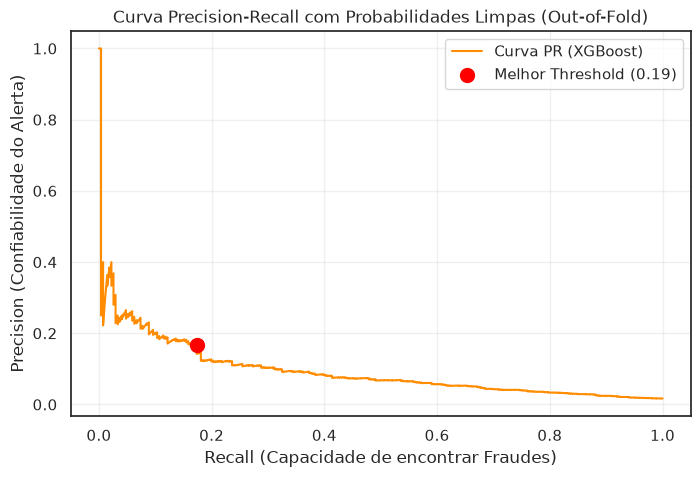

In [36]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve

y_probs_cv_xgb = cross_val_predict(
    xgb_pipeline, 
    X_train, 
    y_train, 
    cv=cv, 
    method="predict_proba",
    n_jobs=-1
)[:, 1]  # Pegamos apenas a coluna da probabilidade de fraude (classe 1)

# Calculando Precision e Recall para todos os thresholds possíveis
precisions, recalls, thresholds_pr = precision_recall_curve(y_train, y_probs_cv_xgb)

# Calculando o F1-Score para cada threshold
# Usamos um pequeno epsilon (1e-8) no denominador para evitar divisão por zero
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

# Encontrando o índice do threshold que gerou o maior F1-Score
best_index = np.argmax(f1_scores)
best_threshold_xgb = thresholds_pr[best_index]
best_f1 = f1_scores[best_index]

print(f"O melhor Threshold encontrado foi: {best_threshold_xgb:.4f}")
print(f"F1-Score máximo projetado: {best_f1:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, label='Curva PR (XGBoost)', color='darkorange')

# Marcando o ponto de melhor threshold
plt.scatter(
    recalls[best_index], 
    precisions[best_index], 
    color='red', 
    s=100, 
    zorder=5, 
    label=f'Melhor Threshold ({best_threshold_xgb:.2f})'
)

plt.xlabel('Recall (Capacidade de encontrar Fraudes)')
plt.ylabel('Precision (Confiabilidade do Alerta)')
plt.title('Curva Precision-Recall com Probabilidades Limpas (Out-of-Fold)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


 Desempenho do XGBoost com Threshold Otimizado (Out-of-Fold)
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     15729
           1       0.17      0.17      0.17       271

    accuracy                           0.97     16000
   macro avg       0.58      0.58      0.58     16000
weighted avg       0.97      0.97      0.97     16000



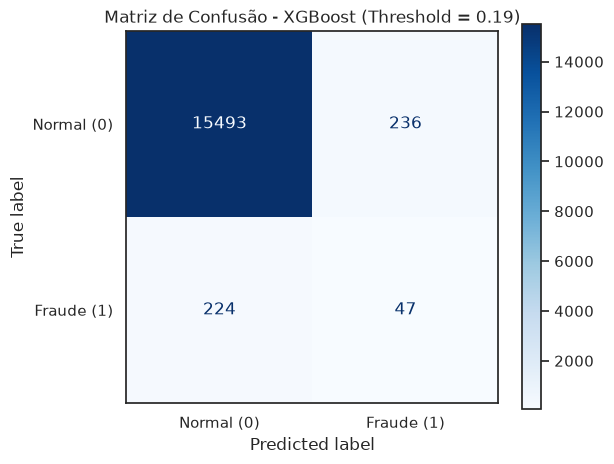

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_otimizado = (y_probs_cv_xgb >= best_threshold_xgb).astype(int)

print("\n Desempenho do XGBoost com Threshold Otimizado (Out-of-Fold)")
print(classification_report(y_train, y_pred_otimizado))

fig, ax = plt.subplots(figsize=(6, 5))
cm_otimizado = confusion_matrix(y_train, y_pred_otimizado)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_otimizado, display_labels=['Normal (0)', 'Fraude (1)'])
disp.plot(cmap='Blues', ax=ax)

plt.title(f'Matriz de Confusão - XGBoost (Threshold = {best_threshold_xgb:.2f})')
plt.show()


O Threshold de 0.19 apresentou o maior F1 entre os thresholds avaliados utilizando a curva de *precision-recall*. No entanto, a curva mostra que o modelo possui limite na separação entre as classes. 

Aumentar o recall resulta em redução da precisão e vice-versa. 

O ajuste permite controlar o trade-off entre falsos positivos e falsos negativos, mas não permite controlar a limitação de separação do modelo. 


 Desempenho do XGBoost em Teste com Threshold Otimizado
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3932
           1       0.16      0.10      0.12        68

    accuracy                           0.98      4000
   macro avg       0.57      0.55      0.56      4000
weighted avg       0.97      0.98      0.97      4000



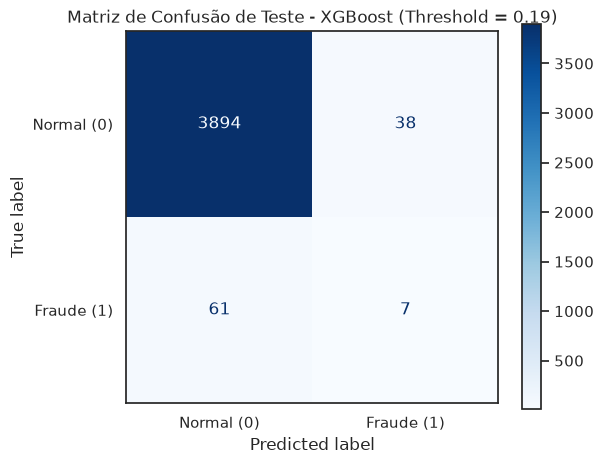

In [38]:
y_pred_scores = xgb_pipeline.predict_proba(X_test)[:, 1]

y_pred = (y_pred_scores >= best_threshold_xgb).astype(int)


print("\n Desempenho do XGBoost em Teste com Threshold Otimizado")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(6, 5))
cm_test = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Normal (0)', 'Fraude (1)'])
disp.plot(cmap='Blues', ax=ax)

plt.title(f'Matriz de Confusão de Teste - XGBoost (Threshold = {best_threshold_xgb:.2f})')
plt.show()


## Conclusão

Encerramos esse notebook.

Devido ao desbalanceamento excessivo e a baixa quantidades de fraudes, os algoritmos não conseguiram distinguir com eficácia uma fronteira que dividisse bem Fraude e Não Fraude.

Ainda é possível utilizar outras abordagens para lidar com o desbalanceamento excessivos, como abordagens a nível de dados como:
- Upsampling / Oversampling da Minoria -> Aumenta a representatividade da classe minoritária;
- Downsampling / Undersampling da Maioria -> Reduz a quantidade de exemplos da classe majoritária.
- Métodos Combinados (Upsampling + Downsampling) -> 

Ou abordagens a nível de algoritmos:
- Modelos de Penalização e Pesos de Classe
- Ajustes em Gradient Boosting e Ensembles
- Ajuste do Limiar de Discriminação


O aprendizado mais importante desse notebook é sobre a avaliação de modelos, em casos de desbalanceamentos excessivos. 

---

**Erick Alves**

Estudante de Análise e Desenvolvimento de Sistemas

* [LinkedIn](www.linkedin.com/in/erick-alvess)
* [GitHub](https://github.com/ErickBritoo)

